In [1]:
import xarray as xr 
import glob
import torch 
import matplotlib.pyplot as plt
import numpy as np
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

In [3]:
# IG = np.load('/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/1981-02-15/tensor_steps24_parrallel_lev00020_lat00149_lon00096.npy')

In [5]:
# IG_s = IG.squeeze()

# # Largest absolute gradient anywhere in each level
# level_abs_max = np.nanmax(np.abs(IG_s), axis=(1, 2))

# # Top 5 levels, sorted from largest to smaller
# top5_levels = np.argsort(level_abs_max)[-5:][::-1]

# for rank, lev in enumerate(top5_levels, start=1):
#     ilat, ilon = np.unravel_index(
#         np.nanargmax(np.abs(IG_s[lev, :, :])),
#         IG_s[lev, :, :].shape,
#     )

#     signed_value = IG_s[lev, ilat, ilon]
#     abs_value = np.abs(signed_value)

#     print(f"Rank {rank}")
#     print("Level:", lev)
#     print("Signed value:", signed_value)
#     print("Absolute value:", abs_value)
#     print("Lat index:", ilat)
#     print("Lon index:", ilon)
#     print()

In [74]:
DATE = '1981-01-15'

DS = xr.open_dataset('/glade/work/wchapman/b.e21.BHIST.f09_g17_Seasonal_Stochai_b050_025_1980.cam.h1.2010-10-13-00000.nc') 
lat = DS["lat"].values if hasattr(DS["lat"], "values") else DS["lat"]
lon = DS["lon"].values if hasattr(DS["lon"], "values") else DS["lon"]

dir_o = "/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/"+DATE+"/"
files = sorted(glob.glob(dir_o+"tensor_steps24_parrallel_lev00020_lat*.npy"))
stacked = np.stack([np.load(f).squeeze()[20+32+32-4].squeeze() for f in files])

mean_IG = np.mean(stacked, axis=0)

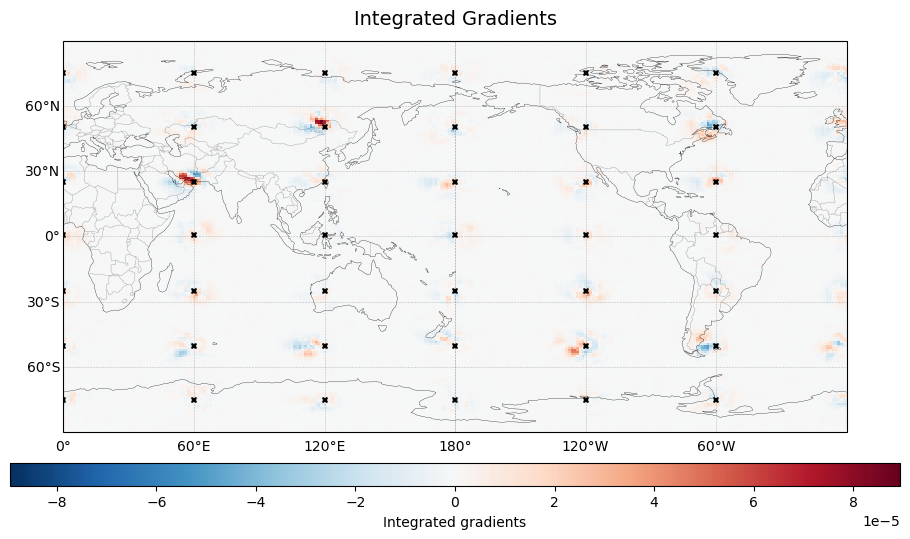

In [75]:
# IG = np.load(dir_o + "tensor_steps24_parrallel_lev00020_lat00122_lon00144.npy").squeeze()
# field_show = IG[20, :, :].squeeze()

# field_cyc, lon_cyc = add_cyclic_point(field_show, coord=lon)
field_cyc, lon_cyc = add_cyclic_point(mean_IG, coord=lon)

vmax = np.nanmax(np.abs(field_cyc))
vmin = -vmax

fig = plt.figure(figsize=(12, 5.5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

im = ax.pcolormesh(
    lon_cyc,
    lat,
    field_cyc,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    shading="auto",
)

lat_idx = [16, 42, 69, 96, 122, 149, 175]
lon_idx = [0, 48, 96, 144, 192, 240]

dot_lat = lat[lat_idx]
dot_lon = lon_cyc[lon_idx]

for vdot_lat in dot_lat:
    for vdot_lon in dot_lon:
        ax.plot(
            vdot_lon,
            vdot_lat,
            marker="X",
            markersize=5,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0,
            transform=ccrs.PlateCarree(),
            zorder=10,
        )

ax.set_global()
ax.coastlines(linewidth=0.22)
ax.add_feature(cfeature.BORDERS, linewidth=0.35, alpha=0.3)
# ax.add_feature(cfeature.LAND, facecolor="0.85", alpha=0.35)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    fraction=0.05,
    aspect=40,
)
cbar.set_label("Integrated gradients")

ax.set_title("Integrated Gradients", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

/glade/derecho/scratch/wchapman/tmp/ipykernel_64825/3662834359.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  t1 = torch.load('/glade/derecho/scratch/wchapman/CUVACAR/i

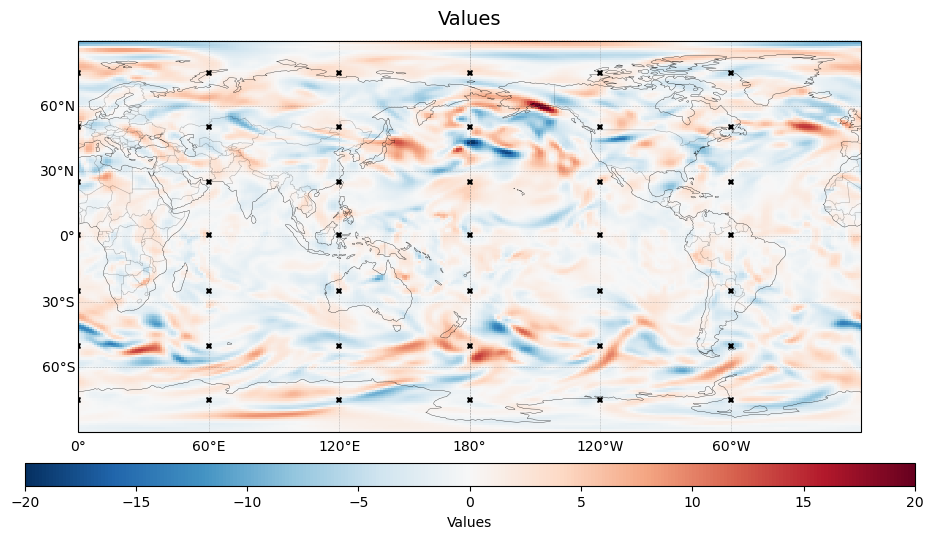

In [90]:
# Difference in values between 00Z and 006Z
t1 = torch.load('/glade/derecho/scratch/wchapman/CUVACAR/init_b2014_1981-01-24_00_00_00_be21_condition_tensor.pth').squeeze().numpy()
t2 = torch.load('/glade/derecho/scratch/wchapman/CUVACAR/init_b2014_1981-01-24_06_00_00_be21_condition_tensor.pth').squeeze().numpy()


fig = plt.figure(figsize=(12, 5.5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
vmin=-20; vmax=20
im = ax.pcolormesh(
    lon_cyc,
    lat,
    t2[20,:,:]-t1[20,:,:],
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    shading="auto",
)

lat_idx = [16, 42, 69, 96, 122, 149, 175]
lon_idx = [0, 48, 96, 144, 192, 240]

dot_lat = lat[lat_idx]
dot_lon = lon_cyc[lon_idx]

for vdot_lat in dot_lat:
    for vdot_lon in dot_lon:
        ax.plot(
            vdot_lon,
            vdot_lat,
            marker="X",
            markersize=5,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0,
            transform=ccrs.PlateCarree(),
            zorder=10,
        )

ax.set_global()
ax.coastlines(linewidth=0.22)
ax.add_feature(cfeature.BORDERS, linewidth=0.35, alpha=0.3)
# ax.add_feature(cfeature.LAND, facecolor="0.85", alpha=0.35)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    fraction=0.05,
    aspect=40,
)
cbar.set_label("Values")

ax.set_title("Values", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

In [26]:
t1 = torch.load('/glade/derecho/scratch/kjmayer/CUVACAR_xai/init_b2014_1981-02-15_00_00_00_be21_condition_tensor.pth').squeeze().numpy()
t1[17+64,:,:]

array([[-1.1896183 , -1.1896183 , -1.1896183 , ..., -1.1896183 ,
        -1.1896183 , -1.1896183 ],
       [-1.1856134 , -1.184724  , -1.1840085 , ..., -1.1883134 ,
        -1.1875011 , -1.186593  ],
       [-1.1380801 , -1.1352531 , -1.1325928 , ..., -1.1464008 ,
        -1.1438751 , -1.1410195 ],
       ...,
       [-1.0249126 , -1.0212257 , -1.0175633 , ..., -1.036063  ,
        -1.0323467 , -1.0286266 ],
       [-0.98062927, -0.97923595, -0.9778426 , ..., -0.9847381 ,
        -0.9833756 , -0.9820039 ],
       [-0.9505733 , -0.9505733 , -0.9505733 , ..., -0.9505733 ,
        -0.9505733 , -0.9505733 ]], dtype=float32)

/glade/derecho/scratch/wchapman/tmp/ipykernel_64825/3424903861.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  climo = torch.load('/glade/derecho/scratch/wchapman/CUVACA

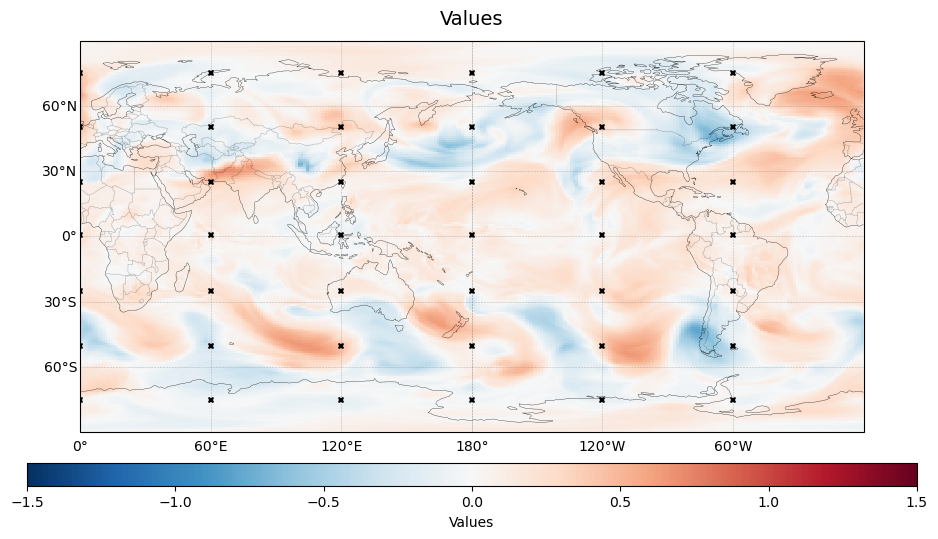

In [82]:
# Difference in values between 00Z and associated climatology
climo = torch.load('/glade/derecho/scratch/wchapman/CUVACAR/init_1981-01-15_00_00_00_be21_condition_tensor_baseline.pth').squeeze().numpy()
t1 = torch.load('/glade/derecho/scratch/kjmayer/CUVACAR_xai/init_b2014_1981-01-15_00_00_00_be21_condition_tensor.pth').squeeze().numpy()


fig = plt.figure(figsize=(12, 5.5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
vmin=-1.5; vmax=1.5
im = ax.pcolormesh(
    lon_cyc,
    lat,
    t1[17+64,:,:]-climo[17+64,:,:],
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    shading="auto",
)

lat_idx = [16, 42, 69, 96, 122, 149, 175]
lon_idx = [0, 48, 96, 144, 192, 240]

dot_lat = lat[lat_idx]
dot_lon = lon_cyc[lon_idx]

for vdot_lat in dot_lat:
    for vdot_lon in dot_lon:
        ax.plot(
            vdot_lon,
            vdot_lat,
            marker="X",
            markersize=5,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0,
            transform=ccrs.PlateCarree(),
            zorder=10,
        )

ax.set_global()
ax.coastlines(linewidth=0.22)
ax.add_feature(cfeature.BORDERS, linewidth=0.35, alpha=0.3)
# ax.add_feature(cfeature.LAND, facecolor="0.85", alpha=0.35)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    fraction=0.05,
    aspect=40,
)
cbar.set_label("Values")

ax.set_title("Values", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

In [51]:
# input concatenated tensor's indexes for each input variable

# U = input_tensor[0:32]
# V = input_tensor[32:64]
# T = input_tensor[64:96]
# Q = input_tensor[96:128]

# TREFHT = input_tensor[129]
# PS = input_tensor[128]

# co2mr_3d = input_tensor[-1]
# ICEFRAC = input_tensor[-2]
# SST = input_tensor[-3]
# SOLIN = input_tensor[-4]
# LANDM_COSLAT = input_tensor[-5]
# z_norm = input_tensor[-6]

In [16]:
dir_o = "/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/"
files = sorted(glob.glob(dir_o+"*/tensor_steps24_parrallel_lev00020_lat00122_lon00144.npy"))[:30]
stackeddate = np.stack([np.load(f).squeeze() for f in files])

meandate_IG = np.mean(stackeddate, axis=0)

In [18]:
files

['/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/1981-01-01/tensor_steps24_parrallel_lev00020_lat00122_lon00144.npy',
 '/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/1981-01-02/tensor_steps24_parrallel_lev00020_lat00122_lon00144.npy',
 '/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/1981-01-03/tensor_steps24_parrallel_lev00020_lat00122_lon00144.npy',
 '/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/1981-01-04/tensor_steps24_parrallel_lev00020_lat00122_lon00144.npy',
 '/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/1981-01-05/tensor_steps24_parrallel_lev00020_lat00122_lon00144.npy',
 '/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/1981-01-06/tensor_steps24_parrallel_lev00020_lat00122_lon00144.npy',
 '/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/1981-01-07/tensor_steps24_parrallel_lev00020_lat00122_lon00144.npy',
 '/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/1981-01-08/tensor_steps24_parrallel_lev00020_lat00122_lon00144.npy',
 '/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/1981-01-09/tenso

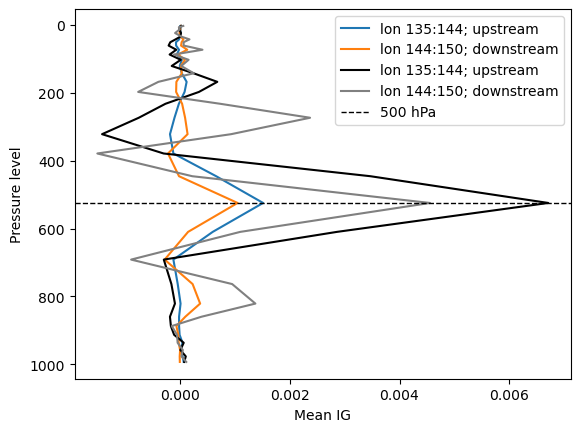

In [24]:
# U, V, T, Q: addval = 0, 32, 64, 96

addval = 0
plt.plot(
    np.mean(np.mean(meandate_IG[0+addval:32+addval, 118:126, 135:144], axis=1), axis=1),
    DS["lev"].values,
    label="lon 135:144; upstream")

plt.plot(
    np.mean(np.mean(meandate_IG[0+addval:32+addval, 118:126, 144:150], axis=1), axis=1),
    DS["lev"].values,
    label="lon 144:150; downstream")

plt.plot(
    np.mean(np.mean(stackeddate[15,0+addval:32+addval, 118:126, 135:144], axis=1), axis=1),
    DS["lev"].values,
    label="lon 135:144; upstream", color='k')

plt.plot(
    np.mean(np.mean(stackeddate[15,0+addval:32+addval, 118:126, 144:150], axis=1), axis=1),
    DS["lev"].values,
    label="lon 144:150; downstream",color='grey')


plt.axhline(
    y=524.6871747076511,
    color="k",
    linestyle="--",
    linewidth=1,
    label="500 hPa",
)

plt.gca().invert_yaxis()
plt.xlabel("Mean IG")
plt.ylabel("Pressure level")
plt.legend()

plt.show()

In [85]:
addval=64
time_space_matrix1 = np.mean(np.mean(stackeddate[:,0+addval:32+addval, 118:126, 135:144],axis=-1),axis=-1)
time_space_matrix2 = np.mean(np.mean(stackeddate[:,0+addval:32+addval, 118:126, 144:150],axis=-1),axis=-1)

import numpy as np

def leading_eof(X):
    """
    X shape: (time, space)
    Returns:
        eigval_frac: leading eigenvalue as fraction of total variance
        eigvec: leading spatial eigenvector, shape (space,)
        pc: leading principal component time series, shape (time,)
    """
    X_anom = X - np.mean(X, axis=0, keepdims=True)

    C = np.cov(X_anom, rowvar=False)

    eigvals, eigvecs = np.linalg.eigh(C)

    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    eigval_frac = eigvals[0] / np.sum(eigvals)
    eigvec = eigvecs[:, 0]

    pc = X_anom @ eigvec

    return eigval_frac, eigvec, pc


# Upstream and downstream matrices
X1 = time_space_matrix1.copy()
X2 = time_space_matrix2.copy()

eigval1, eigvec1, pc1 = leading_eof(X1)
eigval2, eigvec2, pc2 = leading_eof(X2)

# Sign-align downstream mode to upstream mode using temporal PCs
corr = np.corrcoef(pc1, pc2)[0, 1]

if corr < 0:
    eigvec2 = -eigvec2
    pc2 = -pc2
    corr = -corr

print("Upstream leading eigenvalue fraction:")
print(eigval1)

print("Downstream leading eigenvalue fraction:")
print(eigval2)

print("PC correlation after sign alignment:")
print(corr)

print("Upstream leading eigenvector:")
print(eigvec1)

print("Downstream leading eigenvector, temporally sign-aligned:")
print(eigvec2)

Upstream leading eigenvalue fraction:
0.5702103782178639
Downstream leading eigenvalue fraction:
0.6249441486526305
PC correlation after sign alignment:
0.8745989161550775
Upstream leading eigenvector:
[ 0.01472738  0.00743054  0.03476486 -0.01177016 -0.02309672  0.02728207
  0.03647561 -0.01821126 -0.02653398 -0.00073286 -0.01227167 -0.00265636
 -0.01363357  0.02770346  0.01017933  0.14218857  0.04873148 -0.25698591
 -0.59862774 -0.63717684 -0.20456527  0.12409845  0.13799342  0.20173799
  0.1347546   0.06441882  0.02498214  0.01672267  0.01226969  0.00719061
  0.01149347  0.00189498]
Downstream leading eigenvector, temporally sign-aligned:
[ 0.006944   -0.00864954  0.00621952  0.00203526 -0.00169729  0.00911551
  0.01227472  0.01848497  0.0344553   0.01208798  0.00549795  0.00311991
  0.03700265  0.00220813  0.01843288 -0.15229603  0.11055298  0.34064461
  0.57966515  0.4584874  -0.05860117 -0.36729061 -0.31828479 -0.23837046
 -0.03996567 -0.00696758 -0.00453527 -0.0036051   0.001450

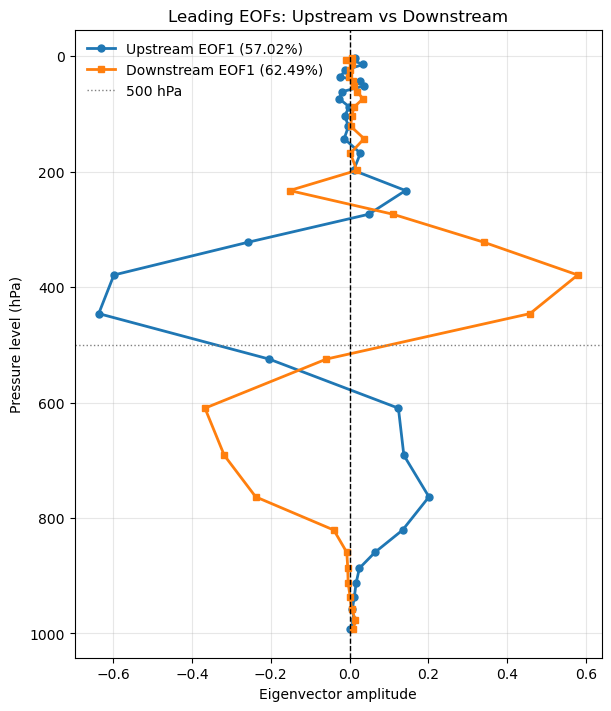

In [64]:
import numpy as np
import matplotlib.pyplot as plt

def leading_eof(X):
    # Remove time mean
    X_anom = X - np.mean(X, axis=0, keepdims=True)

    # Covariance in vertical/space dimension
    C = np.cov(X_anom, rowvar=False)

    # Eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(C)

    # Sort descending
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Leading EOF and PC
    eof1 = eigvecs[:, 0]
    pc1 = X_anom @ eof1

    return eof1, pc1, eigvals[0] / np.sum(eigvals)


# Upstream and downstream
X1 = time_space_matrix1.copy()
X2 = time_space_matrix2.copy()

eof1_up, pc_up, frac_up = leading_eof(X1)
eof1_down, pc_down, frac_down = leading_eof(X2)

# Sign-align downstream to upstream using temporal correlation
if np.corrcoef(pc_up, pc_down)[0, 1] < 0:
    eof1_down = -eof1_down
    pc_down = -pc_down

lev = DS["lev"].values

# Plot both on the same axes
fig, ax = plt.subplots(figsize=(6, 7), constrained_layout=True)

ax.plot(
    eof1_up,
    lev,
    marker="o",
    linewidth=2,
    markersize=5,
    label=f"Upstream EOF1 ({frac_up:.2%})"
)

ax.plot(
    eof1_down,
    lev,
    marker="s",
    linewidth=2,
    markersize=5,
    label=f"Downstream EOF1 ({frac_down:.2%})"
)

ax.axvline(
    x=0,
    color="k",
    linestyle="--",
    linewidth=1
)

ax.axhline(
    y=500,
    color="gray",
    linestyle=":",
    linewidth=1,
    label="500 hPa"
)

ax.invert_yaxis()
ax.set_xlabel("Eigenvector amplitude")
ax.set_ylabel("Pressure level (hPa)")
ax.set_title("Leading EOFs: Upstream vs Downstream")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

plt.show()

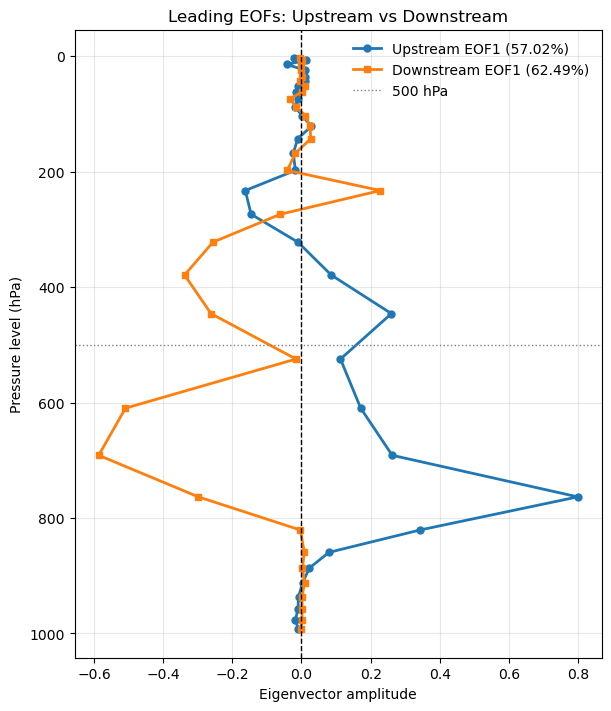

In [65]:
import numpy as np
import matplotlib.pyplot as plt

def leading_eof(X):
    # Remove time mean
    X_anom = X - np.mean(X, axis=0, keepdims=True)

    # Covariance in vertical/space dimension
    C = np.cov(X_anom, rowvar=False)

    # Eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(C)

    # Sort descending
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Leading EOF and PC
    eof1 = eigvecs[:, 1]
    pc1 = X_anom @ eof1

    return eof1, pc1, eigvals[0] / np.sum(eigvals)


# Upstream and downstream
X1 = time_space_matrix1.copy()
X2 = time_space_matrix2.copy()

eof1_up, pc_up, frac_up = leading_eof(X1)
eof1_down, pc_down, frac_down = leading_eof(X2)

# Sign-align downstream to upstream using temporal correlation
if np.corrcoef(pc_up, pc_down)[0, 1] < 0:
    eof1_down = -eof1_down
    pc_down = -pc_down

lev = DS["lev"].values

# Plot both on the same axes
fig, ax = plt.subplots(figsize=(6, 7), constrained_layout=True)

ax.plot(
    eof1_up,
    lev,
    marker="o",
    linewidth=2,
    markersize=5,
    label=f"Upstream EOF1 ({frac_up:.2%})"
)

ax.plot(
    eof1_down,
    lev,
    marker="s",
    linewidth=2,
    markersize=5,
    label=f"Downstream EOF1 ({frac_down:.2%})"
)

ax.axvline(
    x=0,
    color="k",
    linestyle="--",
    linewidth=1
)

ax.axhline(
    y=500,
    color="gray",
    linestyle=":",
    linewidth=1,
    label="500 hPa"
)

ax.invert_yaxis()
ax.set_xlabel("Eigenvector amplitude")
ax.set_ylabel("Pressure level (hPa)")
ax.set_title("Leading EOFs: Upstream vs Downstream")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

plt.show()

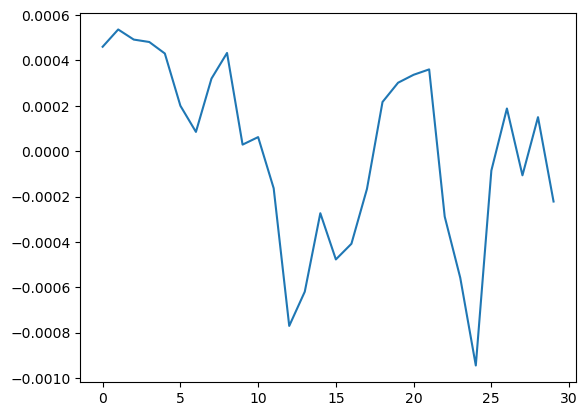

In [87]:
plt.plot(pc_up)